In [21]:
! pip3 install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
     |████████████████████████████████| 4.7 MB 7.7 MB/s eta 0:00:01
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
     |████████████████████████████████| 2.8 MB 6.8 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Consider a distribution: 

$$
p = 
\begin{pmatrix}
0.5 \\
0.3 \\
0.2
\end{pmatrix}
$$

Now consider another distribution:

$$
q = 
\begin{pmatrix}
0.1 \\
0.8 \\
0.1 \\
\end{pmatrix}
$$

For any entry in the $p$ and $q$ distributions, we can say:
$$
q(x) = min(q(x), p(x)) + [q-p]_{+}(x)
$$

For example, take the second entry:

$$
\begin{align}
p(2) &= 0.3 \\
q(2) &= 0.8 \\
min(p(2), q(2)) &= p(2) = 0.3 \\
q(2) - p(2) = 0.5 &\implies [q-p]_{+}(2) = 0.5 \\
q(2) = 0.3 &+ 0.5 = 0.8
\end{align}
$$

Writing in the matrix notation of distributions:

$$
[q-p]_{+} = 
\begin{pmatrix}
0 \\
0.5 \\
0 \\
\end{pmatrix}
\\
min(q, p) = \begin{pmatrix}
0.1 \\
0.3 \\
0.1 \\
\end{pmatrix}
$$

Therefore, it is easy to see:
$$
q(x) =
\begin{pmatrix}
0.1 \\
0.8 \\
0.1 \\
\end{pmatrix} 
= 
\begin{pmatrix}
0.1 \\
0.3 \\
0.1 \\
\end{pmatrix}
+
\begin{pmatrix}
0 \\
0.5 \\
0 \\
\end{pmatrix}
$$

Which in essence, is the key stepping stone to rejection sampling.

Let's code these matrices:

In [12]:
import numpy as np

q = np.array([0.1, 0.8, 0.1])
p = np.array([0.5, 0.3, 0.2])

min_q_p = np.minimum(q, p)
diff_q_p_pos = q-p
diff_q_p_pos[diff_q_p_pos <= 0] = 0


Rejection Sampling uses this clever trick:

$$
q(x) = min(q(x), p(x)) + [q-p]_{+}(x) \implies \\
q(x) = p(x)\cdot min\left(\frac{q(x)}{p(x)}, \frac{p(x)}{p(x)}\right) + [q-p]_{+}(x)\\
q(x) = p(x)\cdot min\left(\frac{q(x)}{p(x)}, 1\right) + [q-p]_{+}(x) 
$$

Let's see this equation in action:

Sampling a value from a distribution $q$ can be broken down into following steps:
- Sample from distribution $p$. Because probability works after many iterations. If you sample from $p$ say $100$ times, you would likely be seeing $1$ sampled $50$ times, $2$ sampled $30$ times and $3$ sampled $20$ times.
- On the contrary, sampling from distribution $q$ $100$ times, you would likely see $1$ $10$ times, $2$ $80$ times and $3$ $10$ times.
- Because we can see $1$ is being under-picked by $p$ comparatively. Sometimes, if $1$ is picked by $p$, we need to reject $1$.


(array([1004., 7974., 1022.]),
 array([0.5, 1.5, 2.5, 3.5]),
 <BarContainer object of 3 artists>)

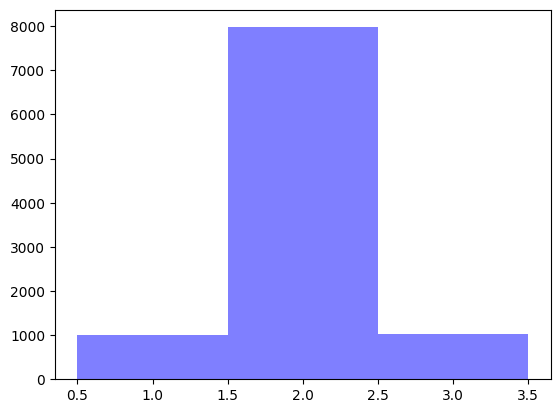

In [33]:
# sample from the distribution q
samples = np.random.choice(list(range(1, len(q) + 1)), size=10000, p=q)
# plot the histogram of the samples with the y-axis not normalized
import matplotlib.pyplot as plt
plt.hist(samples, bins=np.arange(1, len(q) + 2) - 0.5, density=False, alpha=0.5, color='blue', label='Samples from q')


Text(0, 0.5, 'Probability Density')

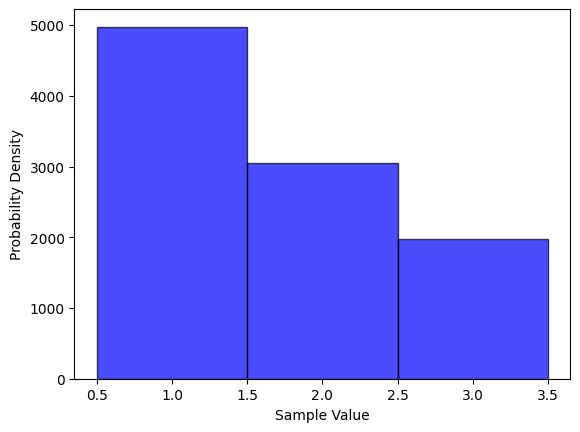

In [34]:
samples = np.random.choice(list(range(1, len(p) + 1)), size=10000, p=p)
# plot the histogram with counts as the y-axis
import matplotlib.pyplot as plt
plt.hist(samples, bins=np.arange(1, len(p) + 2) - 0.5, density=False, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Sample Value')
plt.ylabel('Probability Density')

(array([1048., 3003.,  979.]),
 array([0.5, 1.5, 2.5, 3.5]),
 <BarContainer object of 3 artists>)

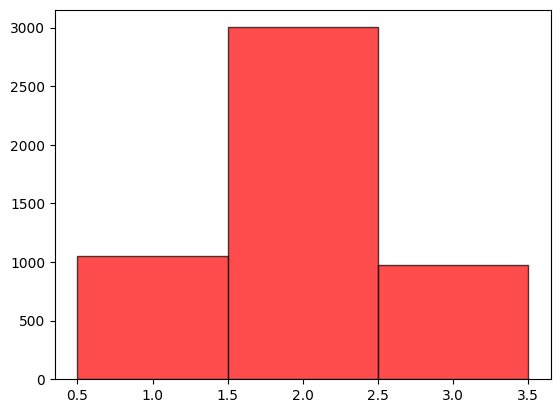

In [35]:
# Now sampling with p, but rejecting samples sometimes based on the value of q/p 
samples = np.random.choice(list(range(1, len(p) + 1)), size=10000, p=p)
acc_samples = []
for s in samples:
    # if p(x) is far more than q(x) reject more often
    if np.random.rand() > q[s - 1] / p[s - 1]:
        pass # rejected
    else:
        acc_samples.append(s)

# plot the histogram with counts as the y-axis
plt.hist(acc_samples, bins=np.arange(1, len(p) + 2) - 0.5, density=False, alpha=0.7, color='red', edgecolor='black')
        

Now the histogram looks more like the distribution $q$. Just one more thing, we are rejecting the samples if they occur with less probability in $q$. What about the samples that occur with higher probability in $q$, but lesser probability in $p$? Maybe once we are rejecting the samples, we should try to find a sample which is more likely. That's how the difference distribution comes into the picture. After the rejection, the values which are under-represented in $p$, choose from them.

(array([1010., 7960., 1030.]),
 array([0.5, 1.5, 2.5, 3.5]),
 <BarContainer object of 3 artists>)

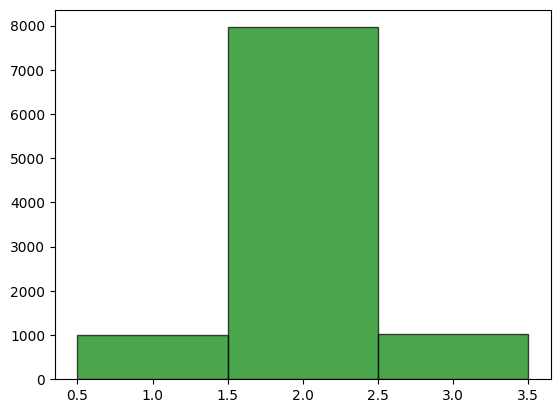

In [36]:
samples = np.random.choice(list(range(1, len(p) + 1)), size=10000, p=p)
acc_samples = []
for s in samples:
    # if p(x) is far more than q(x) reject more often
    if np.random.rand() > q[s - 1] / p[s - 1]:
        # probability of the differential distribution 
        diff_q_p_pos /= np.sum(diff_q_p_pos)
        sample = np.random.choice(list(range(1, len(diff_q_p_pos) + 1)), size=1, p=diff_q_p_pos)
        acc_samples.append(sample[0])
    else:
        acc_samples.append(s)

# plot the histogram with counts as the y-axis
plt.hist(acc_samples, bins=np.arange(1, len(p) + 2) - 0.5, density=False, alpha=0.7, color='green', edgecolor='black')

Voila! Now we have recovered the original distribution back.